<a href="https://colab.research.google.com/github/hye0-n0/hye0-n0/blob/main/ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
raw = pd.read_csv('/content/가격정보.csv', encoding='utf-8')
raw

,구분,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월,연평균
0,2012,"3,500","3,206","3,521","3,660","3,358","3,193","3,004","2,871","3,030","3,050","2,960","3,114","3,201"
1,2013,"3,142","3,465","3,574","3,642","3,526","3,487","3,522","3,171","3,193","3,214","3,204","3,106","3,355"
2,2014,"3,304","3,538","3,403","3,830","3,716","3,522","3,478","3,204","3,186","3,356","3,458","3,608","3,472"
3,2015,"3,714","3,997","3,912","3,636","3,585","3,570","3,001","2,597","2,704","2,722","2,748","2,859","3,246"
4,2016,"2,810","2,958","3,069","3,161","3,322","2,941","2,968","2,946","2,931","2,872","2,852","2,796","2,968"
5,2017,"2,765","2,931","3,029","2,952","3,318","3,094","2,862","2,754","2,731","2,824","2,857","2,976","2,923"
6,2018,"3,054","3,075","3,131","3,302","3,169","3,344","2,976","2,767","2,627","2,633","2,612","2,449","2,930"
7,2019,"2,382","2,360","2,476","2,474","2,486",-,"3,008","2,613","2,640","2,704","2,840","3,032","2,618"
8,2020,"3,229","3,588","3,646","3,378",-,-,"3,273","2,906","3,107","3,017","3,099","3,075","3,205"
9,2021,"3,115","3,302","3,581","3,476","4,137","3,943","3,760","3,431","3,519","3,202","3,483","3,458","3,483"


In [ ]:
col = [i for i in range(1, 13)]
col.insert(0,'year')
col.insert(14, 'mean')
col

['year', 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 'mean']

In [ ]:
raw.columns = col

In [ ]:
raw

,year,1,2,3,4,5,6,7,8,9,10,11,12,mean
0,2012,"3,500","3,206","3,521","3,660","3,358","3,193","3,004","2,871","3,030","3,050","2,960","3,114","3,201"
1,2013,"3,142","3,465","3,574","3,642","3,526","3,487","3,522","3,171","3,193","3,214","3,204","3,106","3,355"
2,2014,"3,304","3,538","3,403","3,830","3,716","3,522","3,478","3,204","3,186","3,356","3,458","3,608","3,472"
3,2015,"3,714","3,997","3,912","3,636","3,585","3,570","3,001","2,597","2,704","2,722","2,748","2,859","3,246"
4,2016,"2,810","2,958","3,069","3,161","3,322","2,941","2,968","2,946","2,931","2,872","2,852","2,796","2,968"
5,2017,"2,765","2,931","3,029","2,952","3,318","3,094","2,862","2,754","2,731","2,824","2,857","2,976","2,923"
6,2018,"3,054","3,075","3,131","3,302","3,169","3,344","2,976","2,767","2,627","2,633","2,612","2,449","2,930"
7,2019,"2,382","2,360","2,476","2,474","2,486",-,"3,008","2,613","2,640","2,704","2,840","3,032","2,618"
8,2020,"3,229","3,588","3,646","3,378",-,-,"3,273","2,906","3,107","3,017","3,099","3,075","3,205"
9,2021,"3,115","3,302","3,581","3,476","4,137","3,943","3,760","3,431","3,519","3,202","3,483","3,458","3,483"


In [ ]:
dfs=[]
for i in range(2,11):
  y = 2012 + i
  raw_y = raw.iloc[i, 1:13]
  raw_y = raw_y.add_prefix(y)
  raw_y = raw_y.T
  raw_y.index = pd.to_datetime(raw_y.index, format='%Y%m')
  dfs.append(raw_y)

In [ ]:
ts = pd.concat([dfs[0],dfs[1],dfs[2],dfs[3], dfs[4], dfs[5], dfs[6], dfs[7], dfs[8]])
ts

2014-01-01    3,304
2014-02-01    3,538
2014-03-01    3,403
2014-04-01    3,830
2014-05-01    3,716
              ...  
2022-08-01        -
2022-09-01        -
2022-10-01        -
2022-11-01        -
2022-12-01        -
Length: 108, dtype: object

In [ ]:
ts = ts['2014-01-01':'2022-07-01']

In [ ]:
ts[ts == '-'] = np.nan

In [ ]:
import re
p = re.compile('\d')

In [ ]:
ts = ts.apply(lambda x: ''.join(p.findall(str(x))))

In [ ]:
ts=pd.to_numeric(ts)
ts

2014-01-01    3304.0
2014-02-01    3538.0
2014-03-01    3403.0
2014-04-01    3830.0
2014-05-01    3716.0
               ...  
2022-03-01    3858.0
2022-04-01       NaN
2022-05-01    5205.0
2022-06-01    4778.0
2022-07-01    3805.0
Length: 103, dtype: float64

In [ ]:
ts_train = ts['2014-01-01':'2021-12-01']

In [ ]:
ts_train

2014-01-01    3304.0
2014-02-01    3538.0
2014-03-01    3403.0
2014-04-01    3830.0
2014-05-01    3716.0
               ...  
2021-08-01    3431.0
2021-09-01    3519.0
2021-10-01    3202.0
2021-11-01    3483.0
2021-12-01    3458.0
Length: 96, dtype: float64

In [ ]:
ts_train.to_csv('/content/ts_train_na.csv')

In [ ]:
ts_test = ts['2022-01-01':]

In [ ]:
ts_test.to_csv('/content/ts_test.csv')

In [ ]:
ts_train_inp= ts_train.interpolate(method='time')

In [ ]:
ts_train_inp

2014-01-01    3304.0
2014-02-01    3538.0
2014-03-01    3403.0
2014-04-01    3830.0
2014-05-01    3716.0
               ...  
2021-08-01    3431.0
2021-09-01    3519.0
2021-10-01    3202.0
2021-11-01    3483.0
2021-12-01    3458.0
Length: 96, dtype: float64

In [ ]:
ts_train_inp.to_csv('/content/ts_train.csv')

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

Text(0.5, 1.0, '고등어 소매 가격')

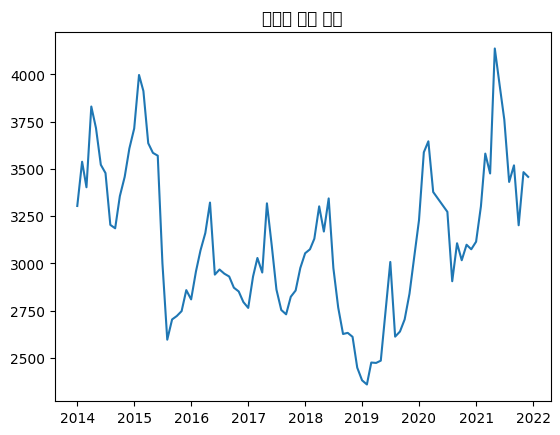

In [ ]:
plt.plot(ts_train_inp)
plt.title('고등어 소매 가격')

In [ ]:
from statsmodels.tsa.arima_model import ARMA
from scipy.stats.distributions import chi2

##AR(1)
model_ar_1 = ARMA(ts_inp, order = (1,0))
result_ar_1 = model_ar_1.fit()
result_ar_1.summary()

/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/arima_model.py:472: FutureWarning: 
statsmodels.tsa.arima_model.ARMA and statsmodels.tsa.arima_model.ARIMA have
been deprecated in favor of statsmodels.tsa.arima.model.ARIMA (note the .
between arima and model) and
statsmodels.tsa.SARIMAX. These will be removed after the 0.12 release.

statsmodels.tsa.arima.model.ARIMA makes use of the statespace framework and
is both well tested and maintained.

To silence this warning and continue using ARMA and ARIMA until they are
removed, use:

import warnings
warnings.filterwarnings('ignore', 'statsmodels.tsa.arima_model.ARMA',
                        FutureWarning)
warnings.filterwarnings('ignore', 'statsmodels.tsa.arima_model.ARIMA',
                        FutureWarning)

  warnings.warn(ARIMA_DEPRECATION_WARN, FutureWarning)
/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/base/tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency MS will be us

<class 'statsmodels.iolib.summary.Summary'>
"""
                              ARMA Model Results                              
==============================================================================
Dep. Variable:                      y   No. Observations:                   67
Model:                     ARMA(1, 0)   Log Likelihood                -466.513
Method:                       css-mle   S.D. of innovations            252.800
Date:                Fri, 25 Nov 2022   AIC                            939.025
Time:                        02:37:21   BIC                            945.640
Sample:                    01-01-2017   HQIC                           941.643
                         - 07-01-2022                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3196.2116    240.141     13.310      0.000    2725.544    3666.879
ar.L1.y        0.8838      0.055     16.182      0.000       0.777       0.991
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            1.1314           +0.0000j            1.1314            0.0000
-----------------------------------------------------------------------------
"""

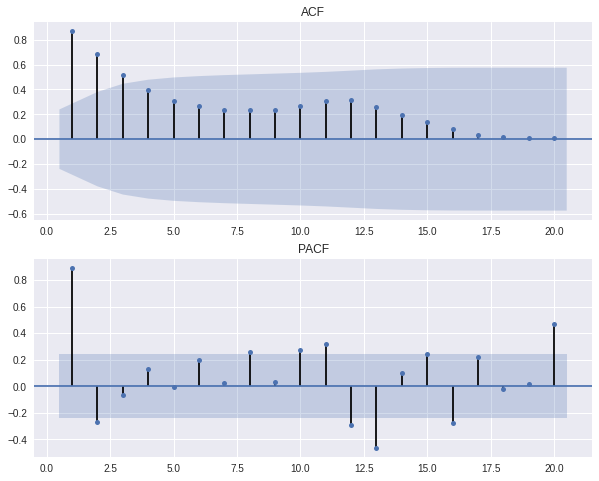

In [ ]:
import statsmodels.graphics.tsaplots as sgt

## Close
fig = plt.figure(figsize=(10,8))
ax1 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2)
plt.style.use('seaborn')

sgt.plot_acf(ts_inp, lags = 20, zero = False, ax=ax1)
ax1.set_title("ACF")


sgt.plot_pacf(ts_inp, lags = 20, zero = False, method = ('ols'), ax=ax2)
ax2.set_title("PACF")

plt.show()

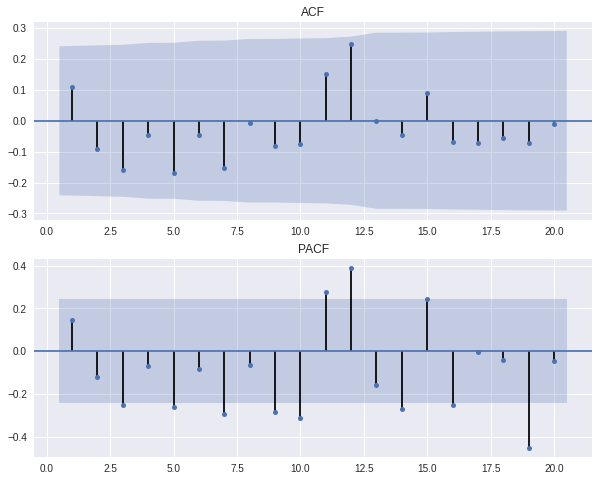

In [ ]:
import statsmodels.graphics.tsaplots as sgt

## Close
fig = plt.figure(figsize=(10,8))
ax1 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2)
plt.style.use('seaborn')

sgt.plot_acf(ts_diff, lags = 20, zero = False, ax=ax1)
ax1.set_title("ACF")


sgt.plot_pacf(ts_diff, lags = 20, zero = False, method = ('ols'), ax=ax2)
ax2.set_title("PACF")

plt.show()

In [ ]:
ts_inp.describe()

count      67.000000
mean     3176.057010
std       545.437265
min      2360.000000
25%      2795.500000
50%      3094.000000
75%      3444.500000
max      5205.000000
dtype: float64

In [ ]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2)

sgt.plot_acf(df['wn'], lags = 20, zero = False, ax=ax1)
ax1.set_title("white noise")


sgt.plot_pacf(df['wn'], lags = 20, zero = False, method = ('ols'), ax=ax2)
ax2.set_title("white noise")

plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

def print_adfuller (x):
    result = adfuller(x)
    print(f'ADF Statistic: {result[0]:.3f}')
    print(f'p-value: {result[1]:.3f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

print_adfuller(ts_inp)
print("-"*30)

ADF Statistic: -2.404
p-value: 0.141
Critical Values:
	1%: -3.535
	5%: -2.907
	10%: -2.591
------------------------------


In [ ]:
from statsmodels.tsa.stattools import adfuller

def print_adfuller (x):
    result = adfuller(x)
    print(f'ADF Statistic: {result[0]:.3f}')
    print(f'p-value: {result[1]:.3f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

print_adfuller(lts)
print("-"*30)


ADF Statistic: -1.720
p-value: 0.421
Critical Values:
	1%: -3.534
	5%: -2.906
	10%: -2.591
------------------------------


In [ ]:
from statsmodels.tsa.stattools import kpss
import pandas as pd

def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"] )

    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)

kpss_test(ts_inp)
kpss_test(lts)
kpss_test(ts_diff)

Results of KPSS Test:
Test Statistic           0.841459
p-value                  0.010000
Lags Used                4.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64
Results of KPSS Test:
Test Statistic           0.822327
p-value                  0.010000
Lags Used                4.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64
Results of KPSS Test:
Test Statistic           0.037466
p-value                  0.100000
Lags Used                1.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/stattools.py:1907: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warn_msg.format(direction="smaller"), InterpolationWarning
/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/stattools.py:1907: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warn_msg.format(direction="smaller"), InterpolationWarning
/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/stattools.py:1911: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warn_msg.format(direction="greater"), InterpolationWarning


In [ ]:
ts_diff = ts_inp.diff(1).dropna()

In [ ]:
ts_diff

2017-02-01    166.000000
2017-03-01     98.000000
2017-04-01    -77.000000
2017-05-01    366.000000
2017-06-01   -224.000000
                 ...    
2022-03-01    119.000000
2022-04-01    684.540984
2022-05-01    662.459016
2022-06-01   -427.000000
2022-07-01   -973.000000
Length: 66, dtype: float64

## LSTM

In [ ]:
ts_train_inp

2014-01-01    3304.0
2014-02-01    3538.0
2014-03-01    3403.0
2014-04-01    3830.0
2014-05-01    3716.0
               ...  
2021-08-01    3431.0
2021-09-01    3519.0
2021-10-01    3202.0
2021-11-01    3483.0
2021-12-01    3458.0
Length: 96, dtype: float64

In [ ]:
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler()

train_sc = sc.fit_transform(pd.DataFrame(ts_train_inp))
train_sc

array([[0.53123241],
       [0.66291503],
       [0.58694429],
       [0.82723692],
       [0.76308385],
       [0.65391109],
       [0.62915025],
       [0.47495779],
       [0.46482836],
       [0.56049522],
       [0.61789533],
       [0.70230726],
       [0.76195836],
       [0.92121553],
       [0.8733821 ],
       [0.71806415],
       [0.6893641 ],
       [0.6809229 ],
       [0.36072032],
       [0.13337085],
       [0.19358469],
       [0.20371412],
       [0.21834553],
       [0.28081035],
       [0.25323579],
       [0.33652223],
       [0.39898706],
       [0.45075971],
       [0.54136185],
       [0.32695554],
       [0.34214969],
       [0.32976927],
       [0.32132808],
       [0.28812606],
       [0.27687113],
       [0.24535734],
       [0.22791221],
       [0.32132808],
       [0.37647721],
       [0.33314575],
       [0.53911086],
       [0.41305571],
       [0.28249859],
       [0.221722  ],
       [0.20877884],
       [0.26111424],
       [0.27968486],
       [0.346

In [ ]:
train_sc_df = pd.DataFrame(train_sc, columns=['price'], index=ts_train_inp.index)
train_sc_df

,price
2014-01-01,0.531232
2014-02-01,0.662915
2014-03-01,0.586944
2014-04-01,0.827237
2014-05-01,0.763084
...,...
2021-08-01,0.602701
2021-09-01,0.652223
2021-10-01,0.473832
2021-11-01,0.631964


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(train_sc_df, test_size=0.2, shuffle=False)

In [ ]:
train_df = pd.DataFrame(train_df, columns=['price'], index=train_df.index)
test_df = pd.DataFrame(test_df, columns=['price'], index=test_df.index)
train_sc_df.head()

,price,shift_1,shift_2,shift_3,shift_4,shift_5,shift_6,shift_7,shift_8,shift_9,shift_10,shift_11,shift_12
2014-01-01,0.531232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-02-01,0.662915,0.531232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-03-01,0.586944,0.662915,0.531232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-01,0.827237,0.586944,0.662915,0.531232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-05-01,0.763084,0.827237,0.586944,0.662915,0.531232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
test_df

,price
2020-05-01,0.553396
2020-06-01,0.533267
2020-07-01,0.513787
2020-08-01,0.307259
2020-09-01,0.420371
2020-10-01,0.369724
2020-11-01,0.415869
2020-12-01,0.402364
2021-01-01,0.424873
2021-02-01,0.530107


In [ ]:
for s in range(1, 13):
    train_df['shift_{}'.format(s)] = train_df['price'].shift(s)
    test_df['shift_{}'.format(s)] = test_df['price'].shift(s)

test_df.head(13)

,price,shift_1,shift_2,shift_3,shift_4,shift_5,shift_6,shift_7,shift_8,shift_9,shift_10,shift_11,shift_12
2020-05-01,0.553396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-06-01,0.533267,0.553396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-07-01,0.513787,0.533267,0.553396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-08-01,0.307259,0.513787,0.533267,0.553396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,0.420371,0.307259,0.513787,0.533267,0.553396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-01,0.369724,0.420371,0.307259,0.513787,0.533267,0.553396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-01,0.415869,0.369724,0.420371,0.307259,0.513787,0.533267,0.553396,NaN,NaN,NaN,NaN,NaN,NaN
2020-12-01,0.402364,0.415869,0.369724,0.420371,0.307259,0.513787,0.533267,0.553396,NaN,NaN,NaN,NaN,NaN
2021-01-01,0.424873,0.402364,0.415869,0.369724,0.420371,0.307259,0.513787,0.533267,0.553396,NaN,NaN,NaN,NaN
2021-02-01,0.530107,0.424873,0.402364,0.415869,0.369724,0.420371,0.307259,0.513787,0.533267,0.553396,NaN,NaN,NaN


In [ ]:
X_train = train_df.dropna().drop('price', axis=1)
y_train = train_df.dropna()[['price']]

X_test = test_df.dropna().drop('price', axis=1)
y_test = test_df.dropna()[['price']]

In [ ]:
X_test.head()

,shift_1,shift_2,shift_3,shift_4,shift_5,shift_6,shift_7,shift_8,shift_9,shift_10,shift_11,shift_12
2021-05-01,0.628025,0.687113,0.530107,0.424873,0.402364,0.415869,0.369724,0.420371,0.307259,0.513787,0.533267,0.553396
2021-06-01,1.000000,0.628025,0.687113,0.530107,0.424873,0.402364,0.415869,0.369724,0.420371,0.307259,0.513787,0.533267
2021-07-01,0.890827,1.000000,0.628025,0.687113,0.530107,0.424873,0.402364,0.415869,0.369724,0.420371,0.307259,0.513787
2021-08-01,0.787845,0.890827,1.000000,0.628025,0.687113,0.530107,0.424873,0.402364,0.415869,0.369724,0.420371,0.307259
2021-09-01,0.602701,0.787845,0.890827,1.000000,0.628025,0.687113,0.530107,0.424873,0.402364,0.415869,0.369724,0.420371


In [ ]:
X_train = X_train.values
X_test= X_test.values

y_train = y_train.values
y_test = y_test.values

print(X_train.shape)
print(y_train.shape)

(64, 12)
(64, 1)


In [ ]:
X_train_ts = X_train.reshape(X_train.shape[0], 12, 1)
X_test_ts = X_test.reshape(X_test.shape[0], 12, 1)
print("최종 DATA")
print(X_train_ts.shape)
print(y_train)

최종 DATA
(64, 12, 1)
[[0.76195836]
 [0.92121553]
 [0.8733821 ]
 [0.71806415]
 [0.6893641 ]
 [0.6809229 ]
 [0.36072032]
 [0.13337085]
 [0.19358469]
 [0.20371412]
 [0.21834553]
 [0.28081035]
 [0.25323579]
 [0.33652223]
 [0.39898706]
 [0.45075971]
 [0.54136185]
 [0.32695554]
 [0.34214969]
 [0.32976927]
 [0.32132808]
 [0.28812606]
 [0.27687113]
 [0.24535734]
 [0.22791221]
 [0.32132808]
 [0.37647721]
 [0.33314575]
 [0.53911086]
 [0.41305571]
 [0.28249859]
 [0.221722  ]
 [0.20877884]
 [0.26111424]
 [0.27968486]
 [0.34665166]
 [0.39054586]
 [0.40236353]
 [0.43387732]
 [0.53010692]
 [0.45526168]
 [0.55374226]
 [0.34665166]
 [0.2290377 ]
 [0.15025324]
 [0.15362971]
 [0.14181204]
 [0.05008441]
 [0.01238042]
 [0.        ]
 [0.06527856]
 [0.06415307]
 [0.07090602]
 [0.2201906 ]
 [0.36465954]
 [0.14237479]
 [0.15756894]
 [0.19358469]
 [0.27011818]
 [0.37816545]
 [0.48902645]
 [0.69105234]
 [0.72369162]
 [0.57287563]]


In [ ]:
import numpy as np
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

In [ ]:
inputs = Input(shape=(12, 1))   # timestep, feature
lstm = LSTM(32)(inputs)
output = Dense(1)(lstm)

model = keras.Model(inputs=inputs, outputs=output)
model.compile(loss='mse', optimizer='adam')
model.summary()

Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_16 (InputLayer)       [(None, 12, 1)]           0         
                                                                 
 lstm_15 (LSTM)              (None, 32)                4352      
                                                                 
 dense_6 (Dense)             (None, 1)                 33        
                                                                 
Total params: 4,385
Trainable params: 4,385
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# 모델 학습, epochs=100 는 100회 학습을 의미한다.
model.fit(X_train_ts, y_train, epochs=100, batch_size=1)

Epoch 1/100
64/64 [==============================] - 2s 5ms/step - loss: 0.0691
Epoch 2/100
64/64 [==============================] - 0s 5ms/step - loss: 0.0409
Epoch 3/100
64/64 [==============================] - 0s 5ms/step - loss: 0.0399
Epoch 4/100
64/64 [==============================] - 0s 6ms/step - loss: 0.0397
Epoch 5/100
64/64 [==============================] - 0s 6ms/step - loss: 0.0362
Epoch 6/100
64/64 [==============================] - 0s 5ms/step - loss: 0.0346
Epoch 7/100
64/64 [==============================] - 0s 5ms/step - loss: 0.0414
Epoch 8/100
64/64 [==============================] - 0s 5ms/step - loss: 0.0297
Epoch 9/100
64/64 [==============================] - 0s 5ms/step - loss: 0.0303
Epoch 10/100
64/64 [==============================] - 0s 6ms/step - loss: 0.0271
Epoch 11/100
64/64 [==============================] - 0s 6ms/step - loss: 0.0315
Epoch 12/100
64/64 [==============================] - 0s 6ms/step - loss: 0.0270
Epoch 13/100
64/64 [=================

In [ ]:
y_pred = model.predict(X_test_ts)
print(y_pred)

1/1 [==============================] - 0s 456ms/step
[[0.65611   ]
 [0.7178101 ]
 [0.6750992 ]
 [0.5959782 ]
 [0.47664165]
 [0.39009172]
 [0.29420152]
 [0.36610502]]


In [ ]:
from sklearn.metrics import mean_squared_error
MSE = mean_squared_error(y_test, y_pred)
np.sqrt(MSE)

0.3174295347319697

In [ ]:
real_y=sc.inverse_transform(y_test)

In [ ]:
real_pre=sc.inverse_transform(y_pred)

In [ ]:
MSE = mean_squared_error(real_y, real_pre)
np.sqrt(MSE)

385.3853728673931

In [ ]:
v=sc.fit_transform(pd.DataFrame(ts_train_inp['2021-01-01':]))

In [ ]:
va=pd.concat([ts_train_inp, ts_test.interpolate(method='time')], axis=0)

In [ ]:
a=sc.fit_transform(pd.DataFrame(va))
#model.predict(a)

In [ ]:
at=a.reshape(-1)